Q1(a) — Gamma Correction with γ=0.5
1. Concept

Gamma correction is an intensity transformation used to make an image brighter or darker in a non-linear way.

The general formula is:

s=r
γ

where:

r = input intensity in [0,1]
s = output intensity
γ = gamma value

When γ<1, dark pixels are expanded, so the image becomes brighter.

For this part:

γ=0.5

So the runway image should become brighter.

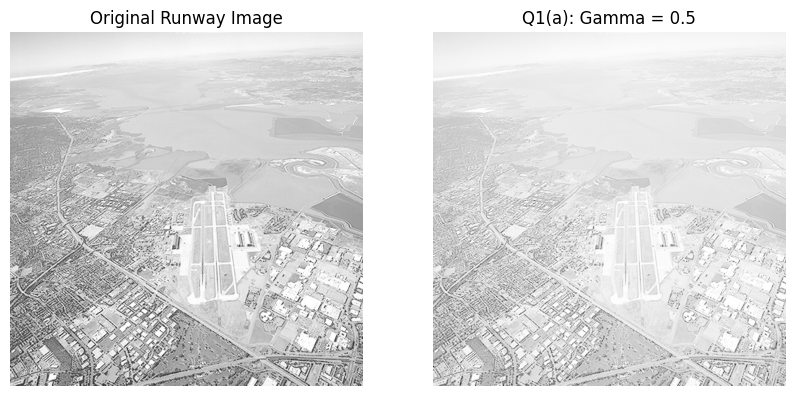

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image as grayscale
img = cv.imread('runway.png', cv.IMREAD_GRAYSCALE)

# Normalize to [0,1]
img_norm = img / 255.0

# Q1(a): gamma correction with gamma = 0.5
gamma_05 = np.power(img_norm, 0.5)

# Convert back to displayable uint8
gamma_05_u8 = np.uint8(np.clip(gamma_05 * 255, 0, 255))

# Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Runway Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gamma_05_u8, cmap='gray')
plt.title('Q1(a): Gamma = 0.5')
plt.axis('off')

plt.show()

### Mapping Curve for Q1(a)

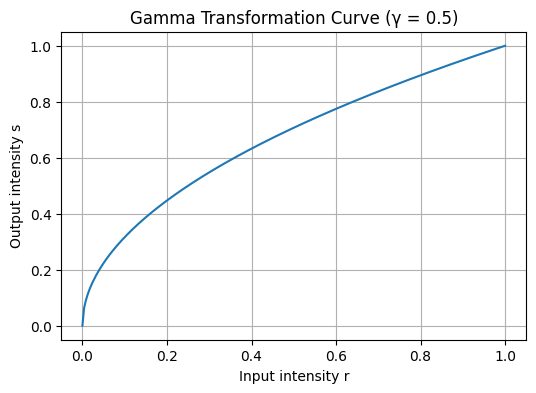

In [2]:
r = np.linspace(0, 1, 256)
s_gamma_05 = r ** 0.5

plt.figure(figsize=(6,4))
plt.plot(r, s_gamma_05)
plt.title('Gamma Transformation Curve (γ = 0.5)')
plt.xlabel('Input intensity r')
plt.ylabel('Output intensity s')
plt.grid(True)
plt.show()

Q1(b) — Gamma Correction with γ=2
1. Concept

Again we use:

s=r
γ

This time:

γ=2

When γ>1, the image becomes darker, because mid-range and low intensities are suppressed.

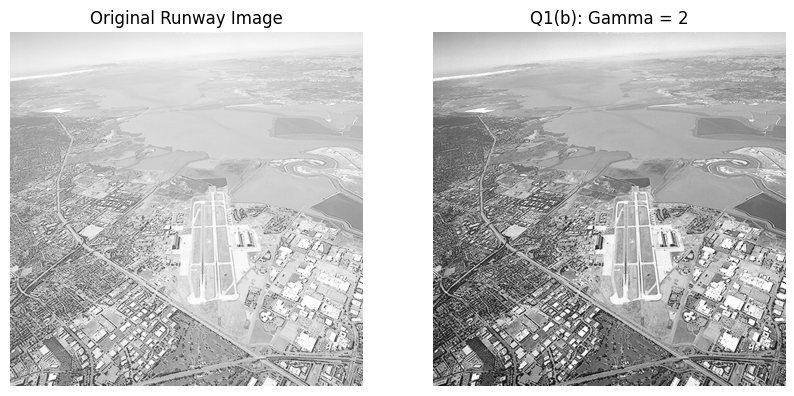

In [9]:
# Q1(b): gamma correction with gamma = 2
gamma_2 = np.power(img_norm, 2.0)

# Convert back to uint8
gamma_2_u8 = np.uint8(np.clip(gamma_2 * 255, 0, 255))

# Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Runway Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gamma_2_u8, cmap='gray')
plt.title('Q1(b): Gamma = 2')
plt.axis('off')

plt.show()

### Mapping Curve for Q1(b)

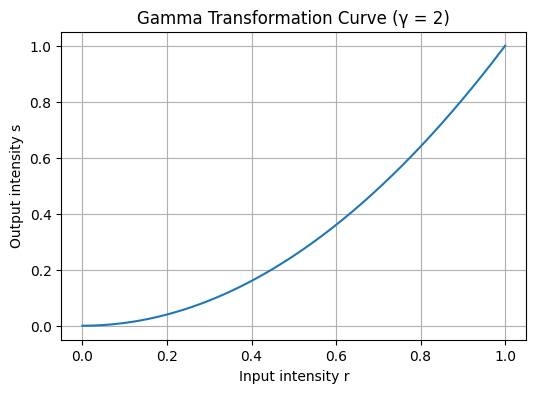

In [6]:
s_gamma_2 = r ** 2

plt.figure(figsize=(6,4))
plt.plot(r, s_gamma_2)
plt.title('Gamma Transformation Curve (γ = 2)')
plt.xlabel('Input intensity r')
plt.ylabel('Output intensity s')
plt.grid(True)
plt.show()

### Interpretation for Q1(c)

### Q1(c) — Contrast Stretching

1. Concept

Contrast stretching is a simple image enhancement technique that improves the contrast of an image by "stretching" the range of pixel intensities. It maps the minimum and maximum pixel values in the original image to the full dynamic range (e.g., 0-255 for an 8-bit image).

The formula for contrast stretching is generally:

s = (r - r_min) * (L-1) / (r_max - r_min)

where:

r = input intensity
s = output intensity
r_min = minimum intensity value in the image
r_max = maximum intensity value in the image
L-1 = maximum output intensity (e.g., 255 for 8-bit)

This makes the image appear more visually distinct by increasing the difference between the darkest and brightest areas.

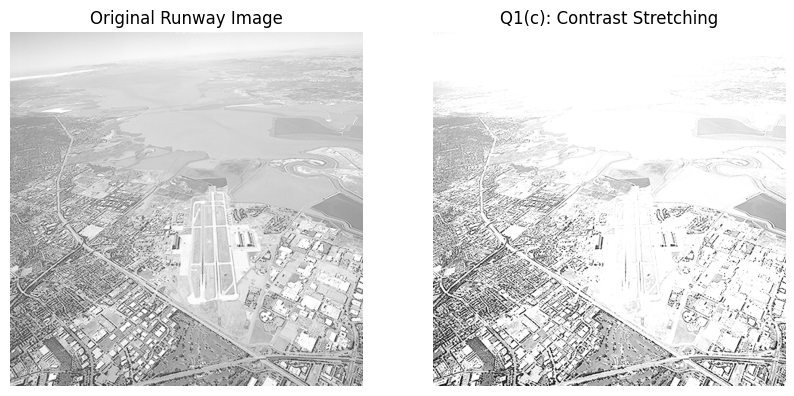

In [13]:
# Q1(c): contrast stretching
r1 = 0.2
r2 = 0.8

contrast_stretched = np.zeros_like(img_norm)

# Apply piecewise transformation
contrast_stretched[img_norm < r1] = 0
mask = (img_norm >= r1) & (img_norm <= r2)
contrast_stretched[mask] = (img_norm[mask] - r1) / (r2 - r1)
contrast_stretched[img_norm > r2] = 1

# Convert back to uint8
contrast_stretched_u8 = np.uint8(np.clip(contrast_stretched * 255, 0, 255))

# Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original Runway Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(contrast_stretched_u8, cmap='gray')
plt.title('Q1(c): Contrast Stretching')
plt.axis('off')

plt.show()

### Transformation Curve for Q1(c)

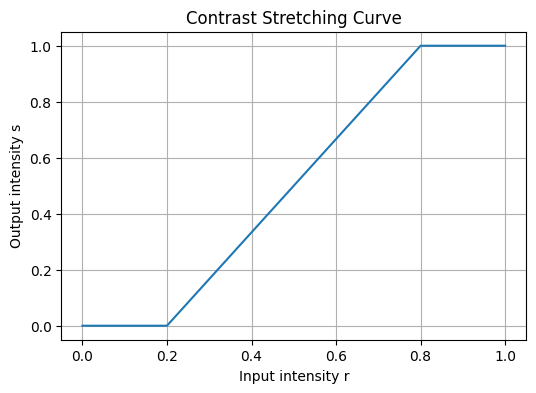

In [14]:
r = np.linspace(0, 1, 256)
s_cs = np.piecewise(
    r,
    [r < r1, (r >= r1) & (r <= r2), r > r2],
    [0, lambda x: (x - r1) / (r2 - r1), 1]
)

plt.figure(figsize=(6,4))
plt.plot(r, s_cs)
plt.title('Contrast Stretching Curve')
plt.xlabel('Input intensity r')
plt.ylabel('Output intensity s')
plt.grid(True)
plt.show()